In [ ]:
# Question 1: Which region has the most service?
# Question 2: What hour has the rarest buses?
# Question 3: Which stops are busiest?
# Question 4: When do buses stop running?
import pandas as pd

# Step 2: Load your data
data = pd.read_csv('data/trips.txt')

# Step 3: Understand what you have
print("Shape of data:", data.shape)  # How many rows and columns?
print("\nFirst 5 rows:")
print(data.head())

print("\nData types:")
print(data.dtypes)

print("\nBasic statistics:")
print(data.describe())

Shape of data: (5191, 6)

First 5 rows:
   route_id service_id         trip_id          trip_headsign  direction_id  \
0        10          3  10_18600_3_1_1  GUSTERITA - TABACARIE             0   
1        10          4  10_18900_4_1_1  GUSTERITA - TABACARIE             0   
2        10          5  10_18900_5_1_1  GUSTERITA - TABACARIE             0   
3        10          3  10_19200_3_0_4               TURNISOR             1   
4        10          4  10_19200_4_0_2               TURNISOR             1   

             shape_id  
0  10.0.304_tabacarie  
1  10.0.304_tabacarie  
2  10.0.304_tabacarie  
3         10.1.199_10  
4         10.1.199_10  

Data types:
route_id         int64
service_id         str
trip_id            str
trip_headsign      str
direction_id     int64
shape_id           str
dtype: object

Basic statistics:
          route_id  direction_id
count  5191.000000   5191.000000
mean    100.530534      0.495666
std     190.925549      0.500029
min       1.000000      0

In [ ]:
data = pd.read_csv('data/trips.txt')

service_by_region = data.groupby('trip_headsign').size()
print("Service by region:")
print(service_by_region)

# Calculate percentage
percentage = (service_by_region / service_by_region.sum() * 100).round(2)
print("\nPercentage of total service:")
print(percentage)

Service by region:
trip_headsign
A. SAGUNA                                      30
AEROPORT                                       74
AUMOVIO                                       124
AUMOVIO - AEROPORT                             10
AUMOVIO - CRISTIAN                             12
                                             ... 
ZONA INDUSTRIALA EST - NEVEON                  29
ZONA INDUSTRIALA EST - SCANDIA                 20
ZONA INDUSTRIALA EST - TABACARIE                2
ZONA INDUSTRIALA SURA MICA - MARQUARDT          3
ZONA INDUSTRIALA SURA MICA - OCNA SIBIULUI      3
Length: 113, dtype: int64

Percentage of total service:
trip_headsign
A. SAGUNA                                     0.58
AEROPORT                                      1.43
AUMOVIO                                       2.39
AUMOVIO - AEROPORT                            0.19
AUMOVIO - CRISTIAN                            0.23
                                              ... 
ZONA INDUSTRIALA EST - NEVEON            

C:\Users\Lena\AppData\Local\Temp\ipykernel_7860\967985164.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hourly_counts, x='hour', y='departures', palette='magma')


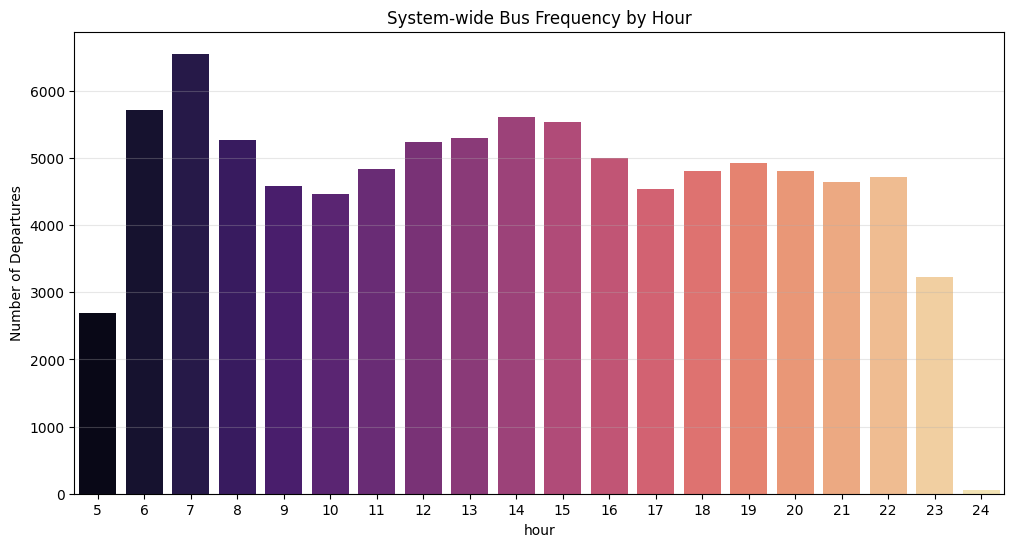

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load GTFS files
routes = pd.read_csv('data/routes.txt')
trips = pd.read_csv('data/trips.txt')
stop_times = pd.read_csv('data/stop_times.txt')
stops = pd.read_csv('data/stops.txt')

# 1. TIME ANALYSIS: When is frequency lowest?
def get_hour(time_str):
    return int(time_str.split(':')[0])

stop_times['hour'] = stop_times['departure_time'].apply(get_hour)
hourly_counts = stop_times.groupby('hour').size().reset_index(name='departures')

# Plotting the hourly frequency
plt.figure(figsize=(12, 6))
sns.barplot(data=hourly_counts, x='hour', y='departures', palette='magma')
plt.title('System-wide Bus Frequency by Hour')
plt.ylabel('Number of Departures')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 2. LOCATION ANALYSIS: Which stops have the longest gaps?
# Calculate time in minutes from midnight
stop_times['min_from_midnight'] = stop_times['departure_time'].apply(
    lambda x: int(x.split(':')[0])*60 + int(x.split(':')[1])
)

# Sort and calculate gaps between consecutive buses at each stop
stop_times = stop_times.sort_values(['stop_id', 'min_from_midnight'])
stop_times['gap'] = stop_times.groupby('stop_id')['min_from_midnight'].diff()

# Find the max gap per stop and merge with stop names
max_gaps = stop_times.groupby('stop_id')['gap'].max().reset_index(name='max_gap_min')
stop_analysis = max_gaps.merge(stops[['stop_id', 'stop_name']], on='stop_id')



In [4]:
# 3. ROUTE ANALYSIS: Which routes have the fewest trips?
route_trips = trips.groupby('route_id').size().reset_index(name='trip_count')
route_info = route_trips.merge(routes[['route_id', 'route_short_name', 'route_long_name']], on='route_id')

print("\nTop 5 Routes with Lowest Daily Trips:")
print(route_info.sort_values(by='trip_count').head(5))


Top 5 Routes with Lowest Daily Trips:
    route_id  trip_count route_short_name  \
28        78           1               E8   
27        77           3               E7   
26        76           3               E6   
24        74           3               E4   
23        73           3               E3   

                                      route_long_name  
28  Transcom - Zăvoi - Șc. Regina Maria - Col. O. ...  
27  Kaufland Arhitectilor - Col. O. Goga - Sc. Reg...  
26         Cireșica - Șc. Regina Maria - Col. O. Goga  
24        Gușterița - Col. O. Goga - Șc. Regina Maria  
23  Cartierul Tineretului  - Col. O. Goga - Șc. Re...  


In [ ]:
import pandas as pd

# 1. Load the GTFS data
# (Ensure the file names match your local files)
stop_times = pd.read_csv('data/stop_times.txt')
stops = pd.read_csv('data/stops.txt')

# 2. Count departures for every stop
# This counts how many times each stop_id appears in the schedule
stop_counts = stop_times['stop_id'].value_counts().reset_index()
stop_counts.columns = ['stop_id', 'departure_count']

# 3. Join with the stops table to get the names
# We connect the counts to the actual names of the stations
stop_analysis = stop_counts.merge(stops[['stop_id', 'stop_name']], on='stop_id')

# 4. Sort from Lowest to Highest
# This puts the "weakest" stops at the very top of the list
lowest_service_stops = stop_analysis.sort_values(by='departure_count', ascending=True)

# 5. Display the results
print("--- TOP 10 LOWEST SERVICE STOPS ---")
print(lowest_service_stops[['departure_count', 'stop_id', 'stop_name']].head(10))

--- TOP 10 LOWEST SERVICE STOPS ---
     departure_count  stop_id                    stop_name
502                1     2558                  Ocna Scoala
501                2     5060                Valea Aurie 3
500                3     2581                      THIMM 1
499                3     2582                      THIMM 2
498                4     2608   Selimbar - Parc Industrial
497                7     2548          IFM-Bilstein Sosire
496                8     2531                     Cașolț 2
478                9    50224            Mai - Curmătura 2
479                9     9205     Păltiniș 3 U (Arka Park)
482                9     9207  Păltiniș 1 U (Arena Platoș)


In [6]:
# Check the schedule for the weakest region (Ocna Scoala)
print("The weakest region (Ocna Scoala)")
weak_region_stops = [2558] # stop_id for Ocna Scoala
weak_schedule = stop_times[stop_times['stop_id'].isin(weak_region_stops)]
print(weak_schedule[['arrival_time', 'departure_time']])

# Check the schedule for the weakest region (Valea Aurie 3)
print("\nThe weakest region ( Valea Aurie 3)")
weak_region_stops = [5060] # stop_id for Valea Aurie 3
weak_schedule = stop_times[stop_times['stop_id'].isin(weak_region_stops)]
print(weak_schedule[['arrival_time', 'departure_time']])

# Check the schedule for the weakest region (THIMM 1)
print("\nThe weakest region (THIMM 1)")
weak_region_stops = [2581] # stop_id for THIMM 1
weak_schedule = stop_times[stop_times['stop_id'].isin(weak_region_stops)]
print(weak_schedule[['arrival_time', 'departure_time']])

# Check the schedule for the weakest region (THIMM 2)
print("\nThe weakest region (THIMM 2)")
weak_region_stops = [2582] # stop_id for THIMM 2
weak_schedule = stop_times[stop_times['stop_id'].isin(weak_region_stops)]
print(weak_schedule[['arrival_time', 'departure_time']])

# Check the schedule for the weakest region (Selimbar - Parc Industrial)
print("\nThe weakest region (Selimbar - Parc Industrial)")
weak_region_stops = [2608] # stop_id for Selimbar - Parc Industrial
weak_schedule = stop_times[stop_times['stop_id'].isin(weak_region_stops)]
print(weak_schedule[['arrival_time', 'departure_time']])

The weakest region (Ocna Scoala)
      arrival_time departure_time
73547     07:54:00       07:54:10

The weakest region ( Valea Aurie 3)
      arrival_time departure_time
85600     07:19:00       07:19:10
85615     11:19:00       11:19:10

The weakest region (THIMM 1)
      arrival_time departure_time
73357     06:29:00       06:29:10
73918     14:04:00       14:04:10
74478     22:34:00       22:34:10

The weakest region (THIMM 2)
      arrival_time departure_time
73328     06:17:00       06:17:10
73929     14:17:00       14:17:10
74529     22:47:00       22:47:10

The weakest region (Selimbar - Parc Industrial)
      arrival_time departure_time
75408     06:14:00       06:14:10
75460     05:50:00       05:50:10
76088     16:56:00       16:56:10
76136     16:50:00       16:50:10
